In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
df = pd.read_csv('../data/ferry_data.csv')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (268195, 4)

First 5 rows:


,_id,Timestamp,Redemption Count,Sales Count
0,1,2026-04-05T23:30:00,7,7
1,2,2026-04-05T23:15:00,1,1
2,3,2026-04-05T23:00:00,4,1
3,4,2026-04-05T22:45:00,2,1
4,5,2026-04-05T22:30:00,4,10


In [4]:
print("Column Names:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nBasic Stats:")
df.describe()

Column Names: ['_id', 'Timestamp', 'Redemption Count', 'Sales Count']

Data Types:
 _id                  int64
Timestamp           object
Redemption Count     int64
Sales Count          int64
dtype: object

Missing Values:
 _id                 0
Timestamp           0
Redemption Count    0
Sales Count         0
dtype: int64

Basic Stats:


,_id,Redemption Count,Sales Count
count,268195.00000,268195.000000,268195.000000
mean,134098.00000,47.999776,48.676922
std,77421.37206,103.453435,98.876845
min,1.00000,0.000000,0.000000
25%,67049.50000,3.000000,3.000000
50%,134098.00000,11.000000,12.000000
75%,201146.50000,39.000000,47.000000
max,268195.00000,7216.000000,7229.000000


In [5]:
# Convert Timestamp to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Extract time features
df['Year'] = df['Timestamp'].dt.year
df['Month'] = df['Timestamp'].dt.month
df['Day'] = df['Timestamp'].dt.day
df['Hour'] = df['Timestamp'].dt.hour
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek  # 0=Monday, 6=Sunday
df['IsWeekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)
df['Season'] = df['Month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall'
})

# Feature Engineering — KPI metrics
df['Total_Activity'] = df['Sales Count'] + df['Redemption Count']
df['Redemption_Pressure_Ratio'] = df['Redemption Count'] / (df['Sales Count'] + 1)
df['Operational_Load_Index'] = (df['Total_Activity'] - df['Total_Activity'].min()) / \
                                (df['Total_Activity'].max() - df['Total_Activity'].min())
df['Is_Idle'] = (df['Total_Activity'] < df['Total_Activity'].quantile(0.25)).astype(int)
df['Is_Congested'] = (df['Total_Activity'] > df['Total_Activity'].quantile(0.75)).astype(int)

print("Features created successfully!")
print(df.shape)
df.head()

Features created successfully!
(268195, 16)


,_id,Timestamp,Redemption Count,Sales Count,Year,Month,Day,Hour,DayOfWeek,IsWeekend,Season,Total_Activity,Redemption_Pressure_Ratio,Operational_Load_Index,Is_Idle,Is_Congested
0,1,2026-04-05 23:30:00,7,7,2026,4,5,23,6,1,Spring,14,0.875000,0.000900,0,0
1,2,2026-04-05 23:15:00,1,1,2026,4,5,23,6,1,Spring,2,0.500000,0.000069,1,0
2,3,2026-04-05 23:00:00,4,1,2026,4,5,23,6,1,Spring,5,2.000000,0.000277,1,0
3,4,2026-04-05 22:45:00,2,1,2026,4,5,22,6,1,Spring,3,1.000000,0.000138,1,0
4,5,2026-04-05 22:30:00,4,10,2026,4,5,22,6,1,Spring,14,0.363636,0.000900,0,0


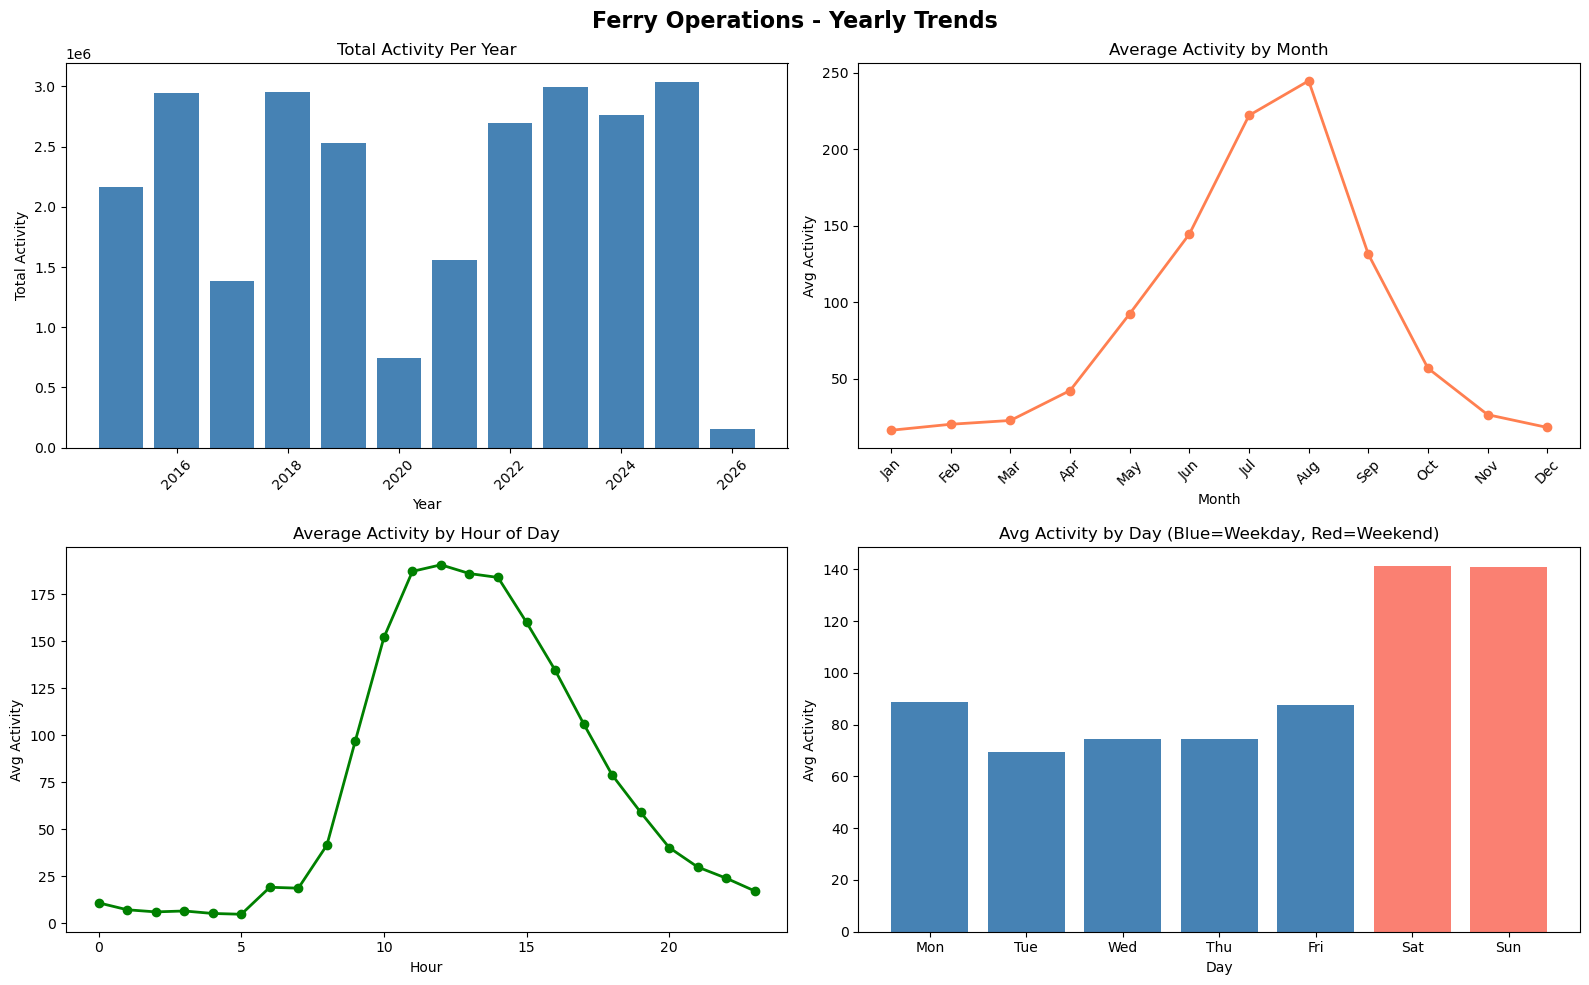

Chart saved!


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Ferry Operations - Yearly Trends', fontsize=16, fontweight='bold')

# Plot 1 - Total activity per year
yearly = df.groupby('Year')['Total_Activity'].sum().reset_index()
axes[0,0].bar(yearly['Year'], yearly['Total_Activity'], color='steelblue')
axes[0,0].set_title('Total Activity Per Year')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Total Activity')
axes[0,0].tick_params(axis='x', rotation=45)

# Plot 2 - Monthly pattern
monthly = df.groupby('Month')['Total_Activity'].mean().reset_index()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[0,1].plot(monthly['Month'], monthly['Total_Activity'], marker='o', color='coral', linewidth=2)
axes[0,1].set_title('Average Activity by Month')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Avg Activity')
axes[0,1].set_xticks(range(1,13))
axes[0,1].set_xticklabels(month_names, rotation=45)

# Plot 3 - Hourly pattern
hourly = df.groupby('Hour')['Total_Activity'].mean().reset_index()
axes[1,0].plot(hourly['Hour'], hourly['Total_Activity'], marker='o', color='green', linewidth=2)
axes[1,0].set_title('Average Activity by Hour of Day')
axes[1,0].set_xlabel('Hour')
axes[1,0].set_ylabel('Avg Activity')

# Plot 4 - Weekday vs Weekend
day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
daily = df.groupby('DayOfWeek')['Total_Activity'].mean().reset_index()
colors = ['salmon' if x >= 5 else 'steelblue' for x in daily['DayOfWeek']]
axes[1,1].bar(day_names, daily['Total_Activity'], color=colors)
axes[1,1].set_title('Avg Activity by Day (Blue=Weekday, Red=Weekend)')
axes[1,1].set_xlabel('Day')
axes[1,1].set_ylabel('Avg Activity')

plt.tight_layout()
plt.savefig('../data/yearly_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

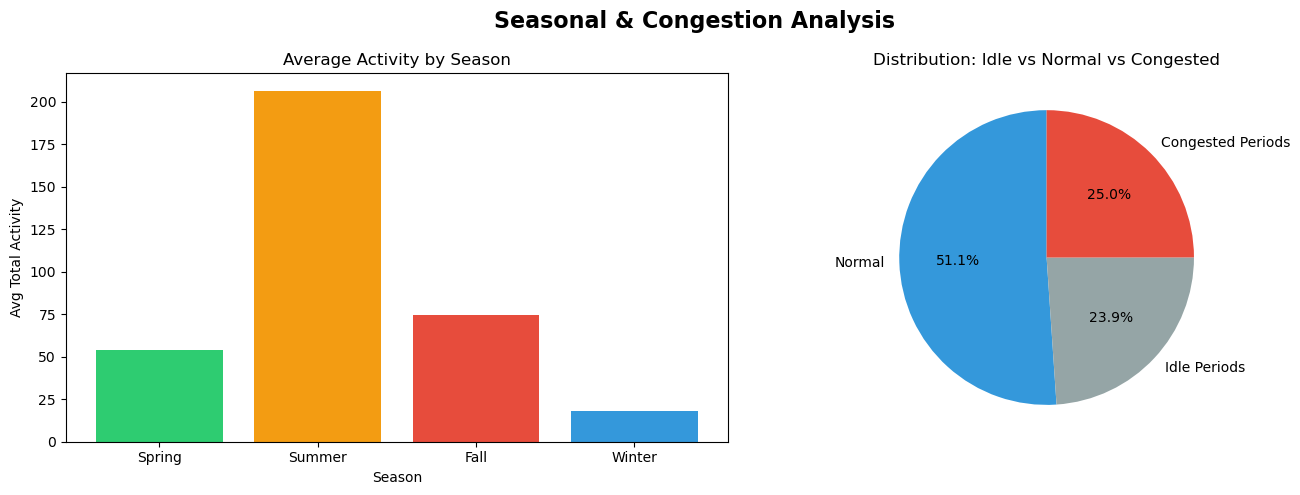

Chart saved!


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Seasonal & Congestion Analysis', fontsize=16, fontweight='bold')

# Plot 1 - Season comparison
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
season_colors = ['#2ecc71', '#f39c12', '#e74c3c', '#3498db']
seasonal = df.groupby('Season')['Total_Activity'].mean().reindex(season_order)
axes[0].bar(season_order, seasonal.values, color=season_colors)
axes[0].set_title('Average Activity by Season')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Avg Total Activity')

# Plot 2 - Idle vs Congested
labels = ['Normal', 'Idle Periods', 'Congested Periods']
sizes = [
    len(df[(df['Is_Idle']==0) & (df['Is_Congested']==0)]),
    df['Is_Idle'].sum(),
    df['Is_Congested'].sum()
]
colors_pie = ['#3498db', '#95a5a6', '#e74c3c']
axes[1].pie(sizes, labels=labels, colors=colors_pie, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Distribution: Idle vs Normal vs Congested')

plt.tight_layout()
plt.savefig('../data/seasonal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [8]:
# ── KPI 1: Capacity Utilization Ratio
utilization_ratio = df['Operational_Load_Index'].mean() * 100

# ── KPI 2: Congestion Pressure Index
congestion_index = (df['Is_Congested'].sum() / len(df)) * 100

# ── KPI 3: Idle Capacity Percentage
idle_percentage = (df['Is_Idle'].sum() / len(df)) * 100

# ── KPI 4: Peak Strain Duration (consecutive congested intervals)
peak_strain = df['Is_Congested'].groupby(
    (df['Is_Congested'] != df['Is_Congested'].shift()).cumsum()
).sum().max()

# ── KPI 5: Operational Variability Score
variability_score = df['Total_Activity'].std() / df['Total_Activity'].mean()

# ── Print all KPIs
print("=" * 45)
print("   FERRY OPERATIONS - KEY PERFORMANCE INDICATORS")
print("=" * 45)
print(f"  Capacity Utilization Ratio  : {utilization_ratio:.2f}%")
print(f"  Congestion Pressure Index   : {congestion_index:.2f}%")
print(f"  Idle Capacity Percentage    : {idle_percentage:.2f}%")
print(f"  Peak Strain Duration        : {peak_strain} intervals")
print(f"  Operational Variability Score: {variability_score:.2f}")
print("=" * 45)

   FERRY OPERATIONS - KEY PERFORMANCE INDICATORS
  Capacity Utilization Ratio  : 0.66%
  Congestion Pressure Index   : 24.99%
  Idle Capacity Percentage    : 23.94%
  Peak Strain Duration        : 64 intervals
  Operational Variability Score: 2.05


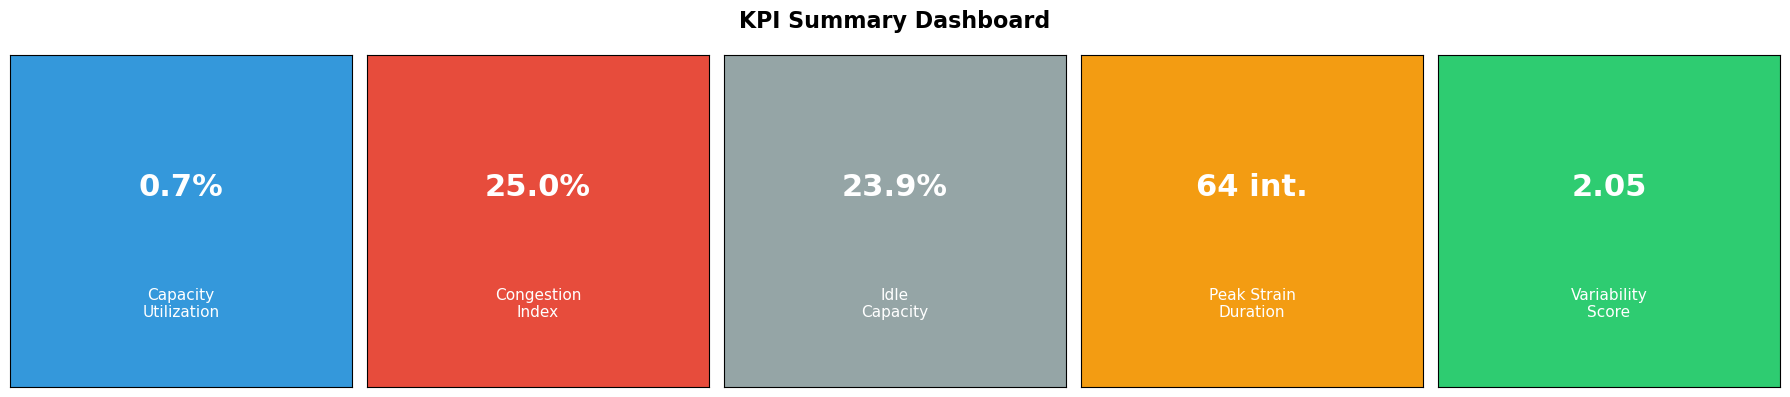

KPI Dashboard saved!


In [9]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle('KPI Summary Dashboard', fontsize=16, fontweight='bold')

kpis = [
    ('Capacity\nUtilization', f'{utilization_ratio:.1f}%', '#3498db'),
    ('Congestion\nIndex', f'{congestion_index:.1f}%', '#e74c3c'),
    ('Idle\nCapacity', f'{idle_percentage:.1f}%', '#95a5a6'),
    ('Peak Strain\nDuration', f'{peak_strain} int.', '#f39c12'),
    ('Variability\nScore', f'{variability_score:.2f}', '#2ecc71'),
]

for ax, (label, value, color) in zip(axes, kpis):
    ax.set_facecolor(color)
    ax.text(0.5, 0.6, value, ha='center', va='center',
            fontsize=22, fontweight='bold', color='white',
            transform=ax.transAxes)
    ax.text(0.5, 0.25, label, ha='center', va='center',
            fontsize=11, color='white', transform=ax.transAxes)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.savefig('../data/kpi_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("KPI Dashboard saved!")

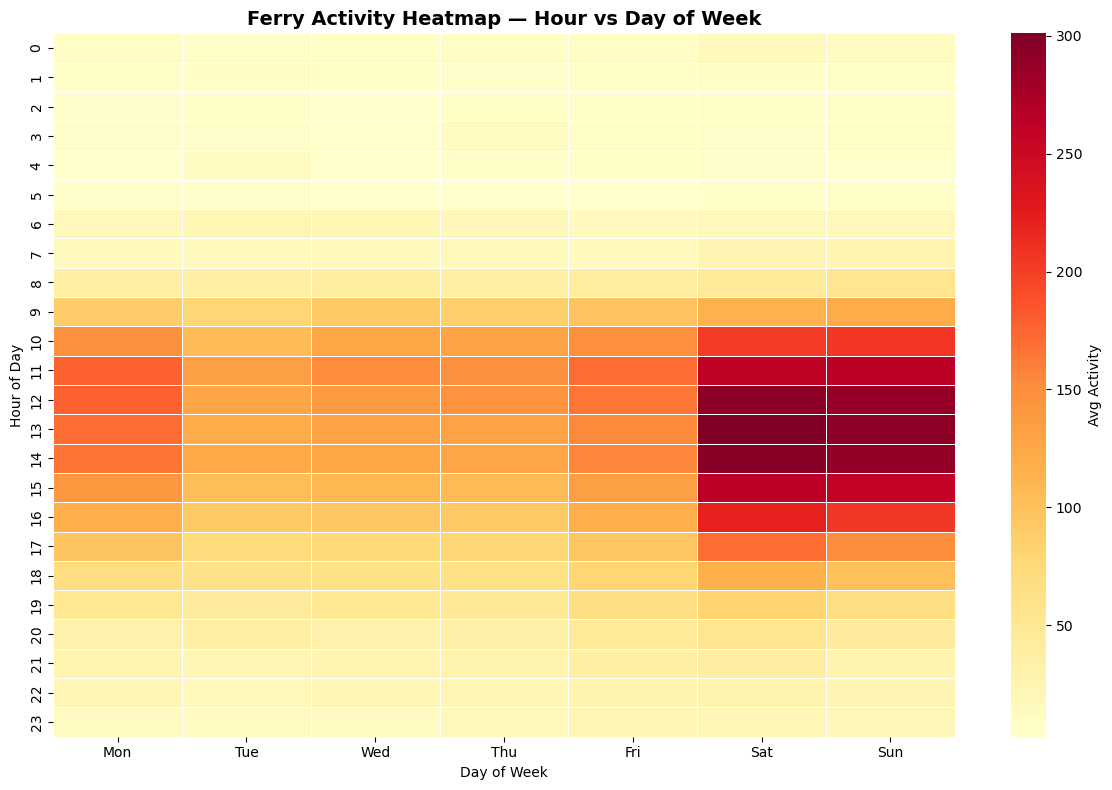

Heatmap saved!


In [10]:
# Pivot table - Hour vs Day of Week
pivot = df.pivot_table(
    values='Total_Activity',
    index='Hour',
    columns='DayOfWeek',
    aggfunc='mean'
)
pivot.columns = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, cmap='YlOrRd', annot=False, fmt='.0f',
            linewidths=0.5, cbar_kws={'label': 'Avg Activity'})
plt.title('Ferry Activity Heatmap — Hour vs Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Hour of Day')
plt.tight_layout()
plt.savefig('../data/heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved!")

In [11]:
# Save the processed dataframe
df.to_csv('../data/ferry_processed.csv', index=False)
print("Processed data saved!")
print(f"Total rows: {len(df)}")
print(f"Total columns: {len(df.columns)}")
print(f"\nColumns saved: {df.columns.tolist()}")

Processed data saved!
Total rows: 268195
Total columns: 16

Columns saved: ['_id', 'Timestamp', 'Redemption Count', 'Sales Count', 'Year', 'Month', 'Day', 'Hour', 'DayOfWeek', 'IsWeekend', 'Season', 'Total_Activity', 'Redemption_Pressure_Ratio', 'Operational_Load_Index', 'Is_Idle', 'Is_Congested']


In [12]:
print("=" * 55)
print("         FERRY OPERATIONS — KEY INSIGHTS")
print("=" * 55)

print(f"\n📅 Data Range: {df['Timestamp'].min().date()} to {df['Timestamp'].max().date()}")
print(f"📊 Total Records: {len(df):,}")

print(f"\n🌞 Busiest Season : Summer")
print(f"❄️  Quietest Season: Winter")

busiest_hour = df.groupby('Hour')['Total_Activity'].mean().idxmax()
quietest_hour = df.groupby('Hour')['Total_Activity'].mean().idxmin()
print(f"\n⏰ Busiest Hour  : {busiest_hour}:00")
print(f"🌙 Quietest Hour : {quietest_hour}:00")

busiest_day = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][
    df.groupby('DayOfWeek')['Total_Activity'].mean().idxmax()
]
print(f"\n📆 Busiest Day   : {busiest_day}")

weekend_avg = df[df['IsWeekend']==1]['Total_Activity'].mean()
weekday_avg = df[df['IsWeekend']==0]['Total_Activity'].mean()
print(f"\n🏖️  Weekend Avg Activity : {weekend_avg:.1f}")
print(f"💼 Weekday Avg Activity : {weekday_avg:.1f}")
print(f"📈 Weekend is {((weekend_avg/weekday_avg)-1)*100:.1f}% busier than weekdays")

print(f"\n⚠️  Congested Intervals : {df['Is_Congested'].sum():,} ({congestion_index:.1f}%)")
print(f"💤 Idle Intervals      : {df['Is_Idle'].sum():,} ({idle_percentage:.1f}%)")
print("=" * 55)

         FERRY OPERATIONS — KEY INSIGHTS

📅 Data Range: 2015-05-01 to 2026-04-05
📊 Total Records: 268,195

🌞 Busiest Season : Summer
❄️  Quietest Season: Winter

⏰ Busiest Hour  : 12:00
🌙 Quietest Hour : 5:00

📆 Busiest Day   : Sat

🏖️  Weekend Avg Activity : 141.1
💼 Weekday Avg Activity : 78.9
📈 Weekend is 78.8% busier than weekdays

⚠️  Congested Intervals : 67,016 (25.0%)
💤 Idle Intervals      : 64,203 (23.9%)


In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np

# Aggregate to daily level for forecasting
daily_df = df.groupby(['Year', 'Month', 'Day']).agg(
    Total_Activity=('Total_Activity', 'sum'),
    Avg_OLI=('Operational_Load_Index', 'mean'),
    Congested_Count=('Is_Congested', 'sum'),
    Idle_Count=('Is_Idle', 'sum')
).reset_index()

# Create date column
daily_df['Date'] = pd.to_datetime(daily_df[['Year','Month','Day']])
daily_df = daily_df.sort_values('Date').reset_index(drop=True)

# Add extra features
daily_df['DayOfWeek'] = daily_df['Date'].dt.dayofweek
daily_df['IsWeekend'] = daily_df['DayOfWeek'].isin([5,6]).astype(int)
daily_df['DayOfYear'] = daily_df['Date'].dt.dayofyear
daily_df['Season'] = daily_df['Month'].map({
    12:'Winter',1:'Winter',2:'Winter',
    3:'Spring',4:'Spring',5:'Spring',
    6:'Summer',7:'Summer',8:'Summer',
    9:'Fall',10:'Fall',11:'Fall'
})
daily_df['Season_Code'] = daily_df['Season'].map(
    {'Winter':0,'Spring':1,'Summer':2,'Fall':3}
)

# 7-day lag feature
daily_df['Lag_7'] = daily_df['Total_Activity'].shift(7)
daily_df['Lag_14'] = daily_df['Total_Activity'].shift(14)
daily_df['Rolling_7'] = daily_df['Total_Activity'].rolling(7).mean()

# Drop nulls from lag
daily_df = daily_df.dropna().reset_index(drop=True)

print("Daily dataset shape:", daily_df.shape)
print(daily_df[['Date','Total_Activity','DayOfWeek','Season']].head(10))

Daily dataset shape: (3973, 16)
        Date  Total_Activity  DayOfWeek  Season
0 2015-05-17           15338          6  Spring
1 2015-05-18           16494          0  Spring
2 2015-05-19            6432          1  Spring
3 2015-05-20            4294          2  Spring
4 2015-05-21            3986          3  Spring
5 2015-05-22            4138          4  Spring
6 2015-05-23           13459          5  Spring
7 2015-05-24           17487          6  Spring
8 2015-05-25            2761          0  Spring
9 2015-05-26            5342          1  Spring


In [14]:
# Features and target
features = ['Year','Month','DayOfWeek','IsWeekend',
            'DayOfYear','Season_Code','Lag_7','Lag_14','Rolling_7']
target = 'Total_Activity'

X = daily_df[features]
y = daily_df[target]

# Train/test split — last 365 days as test
split_idx = len(daily_df) - 365
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Model 1 - Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Model 2 - Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# Results
print("=" * 50)
print("        MODEL PERFORMANCE COMPARISON")
print("=" * 50)
print(f"\n{'Metric':<25} {'Linear Reg':>12} {'Random Forest':>15}")
print("-" * 50)
print(f"{'MAE':<25} {mean_absolute_error(y_test, lr_pred):>12.2f} {mean_absolute_error(y_test, rf_pred):>15.2f}")
print(f"{'RMSE':<25} {np.sqrt(mean_squared_error(y_test, lr_pred)):>12.2f} {np.sqrt(mean_squared_error(y_test, rf_pred)):>15.2f}")
print(f"{'R² Score':<25} {r2_score(y_test, lr_pred):>12.4f} {r2_score(y_test, rf_pred):>15.4f}")
print("=" * 50)


        MODEL PERFORMANCE COMPARISON

Metric                      Linear Reg   Random Forest
--------------------------------------------------
MAE                            2605.98         2006.47
RMSE                           4124.08         3415.36
R² Score                        0.8238          0.8792


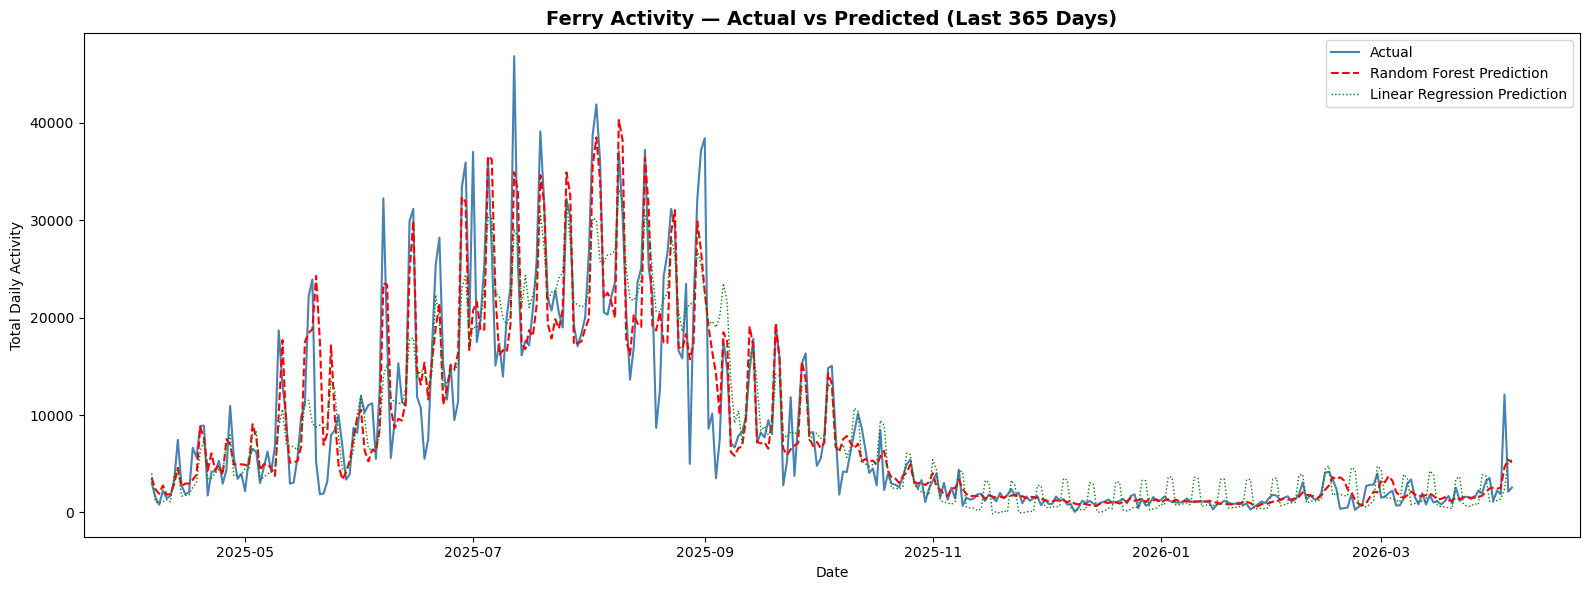

ML chart saved!


In [15]:
test_dates = daily_df['Date'].iloc[split_idx:].reset_index(drop=True)

plt.figure(figsize=(16, 6))
plt.plot(test_dates, y_test.values, label='Actual', color='steelblue', linewidth=1.5)
plt.plot(test_dates, rf_pred, label='Random Forest Prediction',
         color='red', linewidth=1.5, linestyle='--')
plt.plot(test_dates, lr_pred, label='Linear Regression Prediction',
         color='green', linewidth=1, linestyle=':')
plt.title('Ferry Activity — Actual vs Predicted (Last 365 Days)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Daily Activity')
plt.legend()
plt.tight_layout()
plt.savefig('../data/ml_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("ML chart saved!")

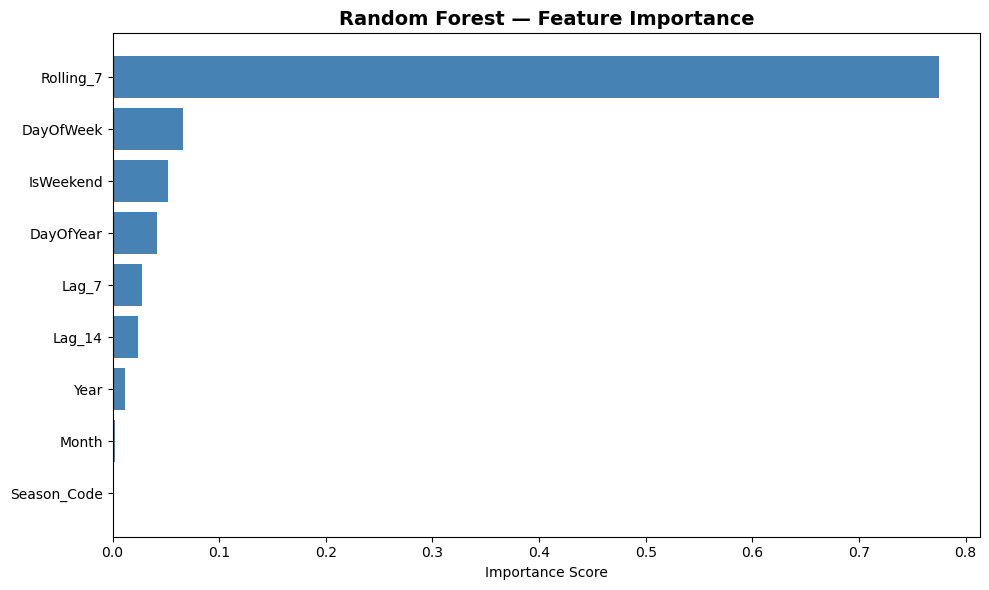

ML data saved!


In [16]:
# Feature importance from Random Forest
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.title('Random Forest — Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Save model results
daily_df['RF_Predicted'] = rf.predict(X)
daily_df.to_csv('../data/ferry_daily_ml.csv', index=False)
print("ML data saved!")